🧩 Building high-resolution mosaic...
✅ Mosaic built successfully. Launching interactive viewer...


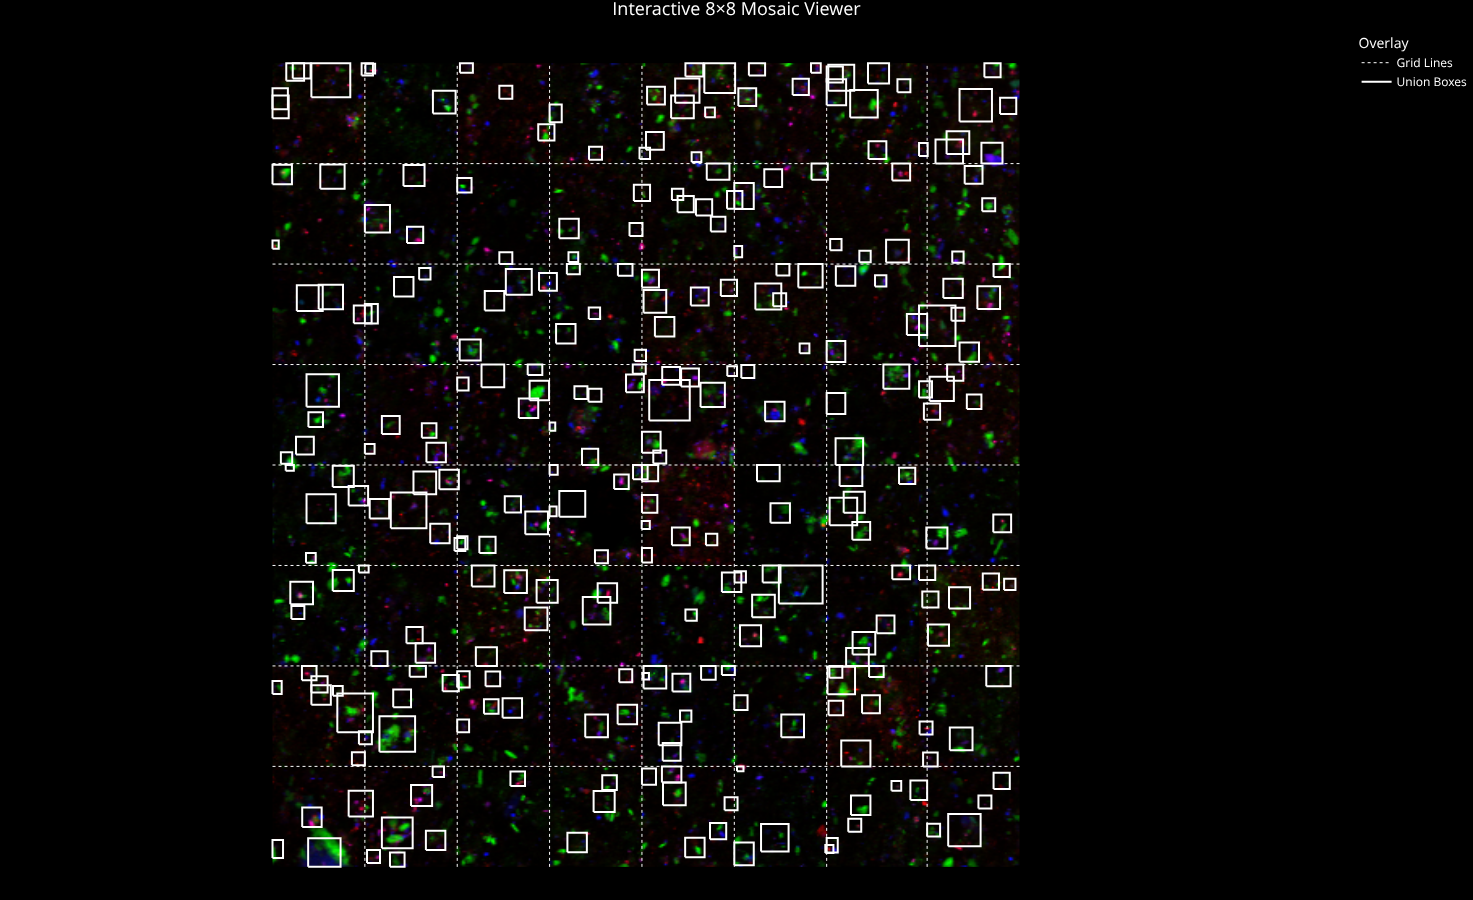

In [2]:
#!/usr/bin/env python3
"""
plotly_mosaic_viewer.py
Generates an 8x8 stitched RGB mosaic from given scan folders
and displays it interactively using Plotly (zoomable, pannable,
with toggleable grid lines and union boxes via legend).
"""

import os
import numpy as np
from PIL import Image
import plotly.graph_objects as go
import plotly.io as pio
import json

# === CONFIG ===
base_root = "/home/codingcarlos/Desktop/Data/Beamline_Data/Automap_2025Q3/all_xrf"
info_path = "/home/codingcarlos/Desktop/Data/Beamline_Data/Automap_2025Q3/data/user_macros"

scan_ids = [
    367582, 367589, 367592, 367596, 367600, 367609, 367614, 367622,
    367630, 367634, 367638, 367641, 367646, 367653, 367658, 367663,
    367667, 367671, 367675, 367680, 367686, 367692, 367698, 367703,
    367710, 367715, 367720, 367726, 367733, 367741, 367744, 367748,
    367754, 367760, 367767, 367772, 367780, 367786, 367789, 367795,
    367798, 367803, 367807, 367813, 367816, 367819, 367825, 367830,
    367837, 367846, 367851, 367857, 367862, 367870, 367873, 367880,
    367885, 367890, 367897, 367899, 367903, 367910, 367915, 367921
]

elements = {
    "R": "detsum_Cu_K_norm.tiff",
    "G": "detsum_Ca_K_norm.tiff",
    "B": "detsum_Fe_K_norm.tiff"
}

# === HELPERS ===
def normalize(arr):
    arr = arr - np.min(arr)
    if np.max(arr) > 0:
        arr = arr / np.max(arr)
    return (arr * 255).astype(np.uint8)

def make_rgb_image(scan_folder):
    channels = {}
    for ch, fname in elements.items():
        path = os.path.join(base_root, scan_folder, fname)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing: {path}")
        arr = np.array(Image.open(path).convert("F"))
        channels[ch] = normalize(arr)
    rgb = np.stack([channels["R"], channels["G"], channels["B"]], axis=-1)
    return Image.fromarray(rgb, mode="RGB")

def stitch_mosaic(scan_ids, grid_size=(8, 8), shift_x=5):
    rows, cols = grid_size
    tile_imgs = []
    tile_size = None
    for sid in scan_ids:
        folder = f"output_tiff_scan2D_{sid}"
        try:
            img = make_rgb_image(folder)
        except FileNotFoundError as e:
            print(e)
            img = Image.new("RGB", (512, 512), (0, 0, 0))
        if tile_size is None:
            tile_size = img.size
        tile_imgs.append(img.resize(tile_size))

    tile_w, tile_h = tile_size
    mosaic_w = cols * tile_w - (cols - 1) * shift_x
    mosaic_h = rows * tile_h
    mosaic = Image.new("RGB", (mosaic_w, mosaic_h))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            if idx >= len(tile_imgs):
                break
            x = j * tile_w - j * shift_x
            y = i * tile_h
            mosaic.paste(tile_imgs[idx], (x, y))
    return mosaic, tile_size

# === PLOTLY DISPLAY ===
def show_plotly_mosaic(mosaic, scan_ids, tile_size, grid_size=(8, 8), shift_x=5):
    img_np = np.array(mosaic)
    h, w, _ = img_np.shape
    n_rows, n_cols = grid_size
    tile_w, tile_h = tile_size

    fig = go.Figure()

    # Add mosaic image
    fig.add_layout_image(
        dict(
            source=Image.fromarray(img_np),
            xref="x", yref="y",
            x=0, y=h,
            sizex=w, sizey=h,
            sizing="stretch",
            layer="below"
        )
    )

    # --- GRID LINES TRACE (vertical lines account for shift_x) ---
    x_lines, y_lines = [], []

    for i in range(1, n_cols):
        x_pos = i * tile_w - i * shift_x if i < n_cols-1 else i * tile_w - (i-1) * shift_x
        x_lines += [x_pos, x_pos, None]
        y_lines += [0, h, None]

    for j in range(1, n_rows):
        y_lines += [j * tile_h, j * tile_h, None]
        x_lines += [0, w, None]

    fig.add_trace(go.Scatter(
        x=x_lines, y=y_lines,
        mode="lines",
        line=dict(color="white", width=1, dash="dot"),
        name="Grid Lines",
        visible=True
    ))

    # --- UNION BOXES TRACE WITH NEGATIVE + BOX #2 SHIFT LOGIC ---
    box_x, box_y = [], []
    hover_texts = []

    for idx, scan_id in enumerate(scan_ids):
        union_json_path = os.path.join(info_path, f"automap_{scan_id}", "unions_output.json")
        if not os.path.exists(union_json_path):
            continue
        with open(union_json_path, "r") as f:
            unions = json.load(f)

        row = idx // n_cols
        col = idx % n_cols

        # Top-left origin for tiles in mosaic
        y_offset = h - (row + 1) * tile_h
        x_offset = col * tile_w - col * shift_x

        for key, obj in unions.items():
            if "image_center" not in obj or "image_length" not in obj:
                continue

            cx, cy = obj["image_center"]
            length = obj["image_length"]
            half = length / 2

            # --- Apply negative/Box #2 shift formula ---
            x_shift_tile = tile_w / 2
            y_shift_tile = tile_h / 2
            if cx < 0 or cy < 0:
                cx += x_shift_tile
                cy += y_shift_tile

            # Compute rectangle edges (origin = top-left of tile)
            left   = x_offset + cx - half
            right  = x_offset + cx + half
            top    = y_offset + (tile_h - cy) - half  # Flip Y axis
            bottom = y_offset + (tile_h - cy) + half

            # Clip to tile boundaries
            left   = max(x_offset, left)
            right  = min(x_offset + tile_w, right)
            top    = max(y_offset, top)
            bottom = min(y_offset + tile_h, bottom)

            # Ensure valid rectangle
            if left > right: left, right = right, left
            if top > bottom: top, bottom = bottom, top

            # Rectangle as closed polygon
            box_x += [left, right, right, left, left, None]
            box_y += [top, top, bottom, bottom, top, None]
            hover_texts += [f"ID: {scan_id}<br>Center: ({cx:.1f}, {cy:.1f})"] * 6

    fig.add_trace(go.Scatter(
        x=box_x, y=box_y,
        mode="lines",
        line=dict(color="white", width=2),
        name="Union Boxes",
        text=hover_texts,
        hoverinfo="text",
        visible=True
    ))

    # Axes config
    fig.update_xaxes(visible=False, range=[0, w])
    fig.update_yaxes(visible=False, range=[0, h], scaleanchor="x")

    # Layout
    fig.update_layout(
        width=900, height=900,
        margin=dict(l=0,r=0,t=30,b=0),
        paper_bgcolor="black",
        plot_bgcolor="black",
        showlegend=True,
        legend=dict(title="Overlay", x=1.05, y=1, bgcolor="rgba(0,0,0,0.5)", font=dict(color="white")),
        title=dict(text="Interactive 8×8 Mosaic Viewer", x=0.5, xanchor="center", font=dict(size=18,color="white"))
    )

    pio.show(fig)

# === MAIN ===
if __name__ == "__main__":
    print("🧩 Building high-resolution mosaic...")
    mosaic, tile_size = stitch_mosaic(scan_ids, grid_size=(8, 8), shift_x=5)
    print("✅ Mosaic built successfully. Launching interactive viewer...")
    show_plotly_mosaic(mosaic, scan_ids, tile_size, grid_size=(8, 8), shift_x=5)


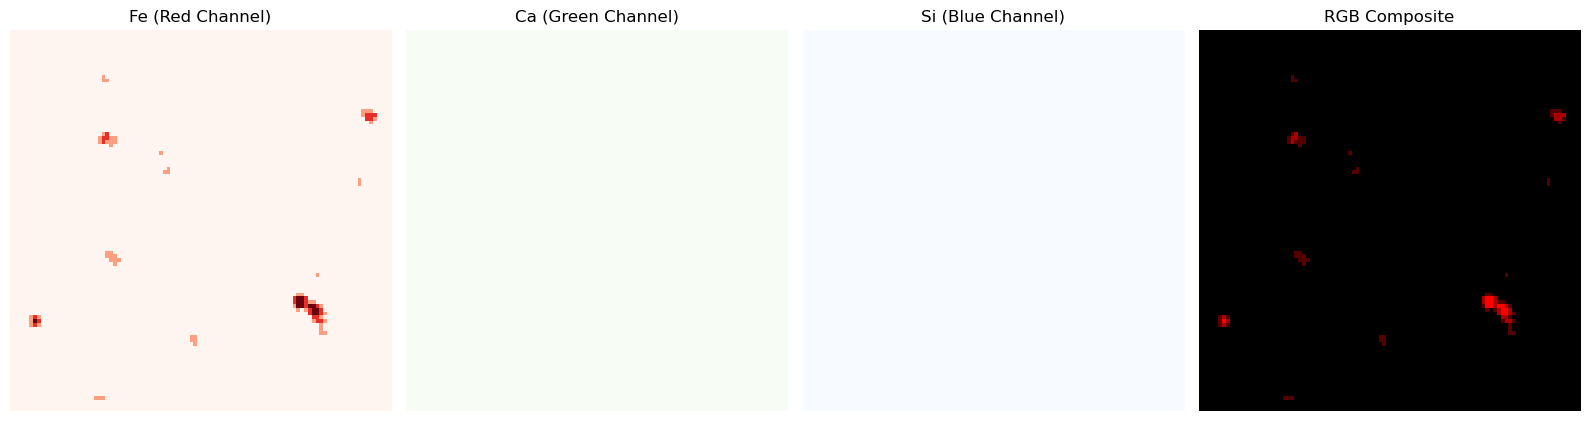

In [2]:
# === FeCaSi Composite Display ===
# Author: ChatGPT (GPT-5)
# Description:
#   Loads Fe, Ca, and Si .tiff images from the specified folder
#   Displays each one as a colored channel (R, G, B)
#   Then shows a merged RGB composite.

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# === CONFIG ===
folder = "/home/codingcarlos/Desktop/Data/Beamline_Data/Automap_2025Q3/automap_369127"
elements = ["Fe", "Ca", "Si"]  # expected image suffixes

# === LOAD IMAGES ===
images = {}
for elem in elements:
    path = os.path.join(folder, f"scan_369127_{elem}.tiff")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image not found: {path}")
    img = np.array(Image.open(path).convert("L"))  # grayscale
    images[elem] = img

# === NORMALIZE FUNCTION ===
def normalize(img):
    img = img.astype(float)
    img -= img.min()
    if img.max() > 0:
        img /= img.max()
    return img

# === NORMALIZE ALL ===
for elem in images:
    images[elem] = normalize(images[elem])

# === CREATE RGB COMPOSITE ===
# Fe → Red, Ca → Green, Si → Blue
rgb = np.dstack([
    images["Fe"],  # R
    images["Ca"],  # G
    images["Si"]   # B
])

# === DISPLAY ===
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
axs[0].imshow(images["Fe"], cmap="Reds")
axs[0].set_title("Fe (Red Channel)")
axs[1].imshow(images["Ca"], cmap="Greens")
axs[1].set_title("Ca (Green Channel)")
axs[2].imshow(images["Si"], cmap="Blues")
axs[2].set_title("Si (Blue Channel)")
axs[3].imshow(rgb)
axs[3].set_title("RGB Composite")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


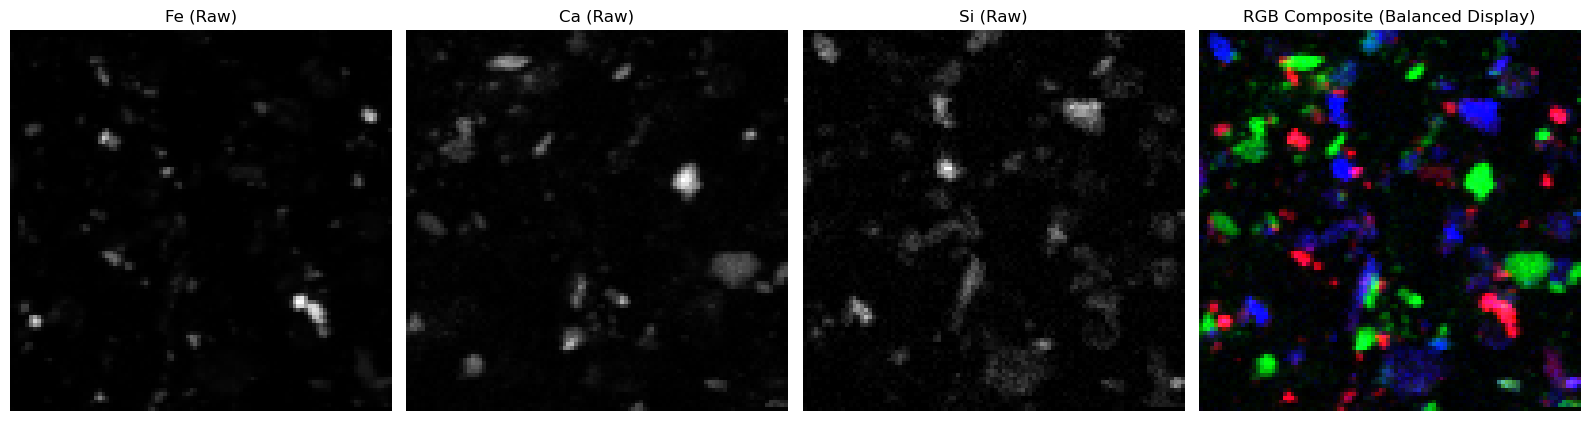

In [3]:
# === FeCaSi Composite Display (Balanced for Visualization) ===
# Author: ChatGPT (GPT-5)
# Description:
#   Loads Fe, Ca, and Si .tiff images from the specified folder
#   Displays them as-is individually (no normalization)
#   Creates a balanced RGB composite for visualization only.

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# === CONFIG ===
folder = "/home/codingcarlos/Desktop/Data/Beamline_Data/Automap_2025Q3/automap_369127"
elements = ["Fe", "Ca", "Si"]

# === LOAD IMAGES ===
images = {}
for elem in elements:
    path = os.path.join(folder, f"scan_369127_{elem}.tiff")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image not found: {path}")
    img = np.array(Image.open(path))
    images[elem] = img

# === ALIGN SHAPES ===
min_shape = np.min([img.shape for img in images.values()], axis=0)
for elem in images:
    images[elem] = images[elem][:min_shape[0], :min_shape[1]]

# === BALANCE EACH CHANNEL FOR DISPLAY ===
# (scales each image to 0–1 separately, *display only*)
def to_display_scale(img):
    img = img.astype(float)
    img_min, img_max = np.percentile(img, (1, 99))  # robust min/max ignoring outliers
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    img = np.clip(img, 0, 1)
    return img

rgb = np.dstack([
    to_display_scale(images["Fe"]),  # R
    to_display_scale(images["Ca"]),  # G
    to_display_scale(images["Si"]),  # B
])

# === DISPLAY ===
fig, axs = plt.subplots(1, 4, figsize=(16, 5))

axs[0].imshow(images["Fe"], cmap="gray")
axs[0].set_title("Fe (Raw)")
axs[1].imshow(images["Ca"], cmap="gray")
axs[1].set_title("Ca (Raw)")
axs[2].imshow(images["Si"], cmap="gray")
axs[2].set_title("Si (Raw)")
axs[3].imshow(rgb)
axs[3].set_title("RGB Composite (Balanced Display)")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


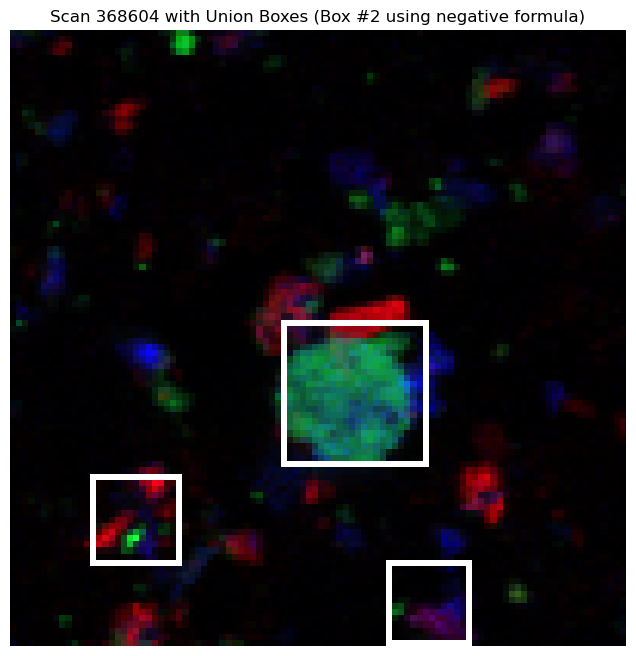

In [52]:
import os
import json
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# --- CONFIG ---
scan_id = 368343#604
scan_dir = f"/home/codingcarlos/Documents/github/SULI-2025-Summer/data/scans_grouped/{scan_id}"

# --- Load Elemental TIFFs ---
ELEMENTS = ["Ca", "Fe", "Si"]
paths = {el: os.path.join(scan_dir, f"scan_{scan_id}_{el}.tiff") for el in ELEMENTS}

def normalize(arr):
    arr = arr.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
    return arr.astype(np.uint8)

imgs = {el: np.array(Image.open(paths[el])) for el in ELEMENTS}
r, g, b = normalize(imgs["Ca"]), normalize(imgs["Fe"]), normalize(imgs["Si"])
rgb = np.stack([r, g, b], axis=-1)

# --- Load and Draw Boxes ---
json_path = os.path.join(scan_dir, "unions_output_FeCaSi.json")
pil_img = Image.fromarray(rgb, 'RGB')

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    draw = ImageDraw.Draw(pil_img)
    w, h = pil_img.size  # image width, height

    # Shift value for negative boxes
    x_shift = w / 2
    y_shift = h / 2

    for name, item in data.items():
        if "image_center" in item and "image_length" in item:
            cx, cy = item["image_center"]
            L = item["image_length"]
            half = L / 2

            # Apply shift formula for negatives AND Box #2 explicitly
            if cx < 0 or cy < 0 or name.endswith("#2"):
                x = cx + x_shift
                y = cy + y_shift
            else:
                x = cx
                y = cy

            # Compute box edges
            left   = x - half
            right  = x + half
            top    = y - half
            bottom = y + half

            # Clip to image boundaries
            left   = max(0, left)
            right  = min(w - 1, right)
            top    = max(0, top)
            bottom = min(h - 1, bottom)

            # Ensure valid rectangle
            if left > right: left, right = right, left
            if top > bottom: top, bottom = bottom, top

            draw.rectangle([left, top, right, bottom], outline="white", width=1)

# --- Display ---
plt.figure(figsize=(8, 8))
plt.imshow(pil_img)
plt.title(f"Scan {scan_id} with Union Boxes (Box #2 using negative formula)")
plt.axis("off")
plt.show()


Box #2:
  Original center: (11.0, 37.0)
  Shift applied: False
  Drawn coordinates: left=5.0, top=31.0, right=17.0, bottom=43.0
  Box length: 12.0, half: 6.0
  Image size: w=100, h=100


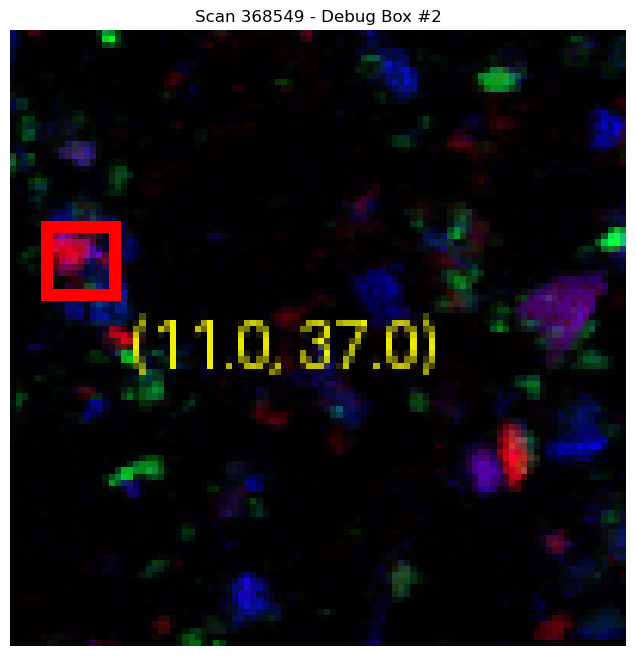

In [43]:
import os
import json
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# --- CONFIG ---
scan_id = 368549
scan_dir = f"/home/codingcarlos/Documents/github/SULI-2025-Summer/data/scans_grouped/{scan_id}"

# --- Load Elemental TIFFs ---
ELEMENTS = ["Ca", "Fe", "Si"]
paths = {el: os.path.join(scan_dir, f"scan_{scan_id}_{el}.tiff") for el in ELEMENTS}

def normalize(arr):
    arr = arr.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
    return arr.astype(np.uint8)

imgs = {el: np.array(Image.open(paths[el])) for el in ELEMENTS}
r, g, b = normalize(imgs["Ca"]), normalize(imgs["Fe"]), normalize(imgs["Si"])
rgb = np.stack([r, g, b], axis=-1)

# --- Load Box JSON ---
json_path = os.path.join(scan_dir, "unions_output_FeCaSi.json")
pil_img = Image.fromarray(rgb, 'RGB')

def parse_coord(val):
    """Parse coordinate, handle 'JS' suffix, return float"""
    if isinstance(val, str):
        val = val.split("JS:")[0]
    return float(val)

# --- User input: which box to debug/display ---
n = 2  # change this to the box number you want

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        data_list = list(json.load(f).values())  # convert dict to list
    
    if n < 1 or n > len(data_list):
        raise ValueError(f"n={n} out of range (1-{len(data_list)})")
    
    item = data_list[n-1]  # 1-based index

    draw = ImageDraw.Draw(pil_img)
    w, h = pil_img.size
    x_shift = w / 2
    y_shift = h / 2

    # --- Parse box info ---
    cx = parse_coord(item["image_center"][0])
    cy = parse_coord(item["image_center"][1])
    L = float(item["image_length"])
    half = L / 2

    # Apply shift only if any coordinate is negative
    if cx < 0 or cy < 0:
        x = cx + x_shift
        y = cy + y_shift
        shifted = True
    else:
        x = cx
        y = cy
        shifted = False

    # Compute box edges
    left   = max(0, x - half)
    right  = min(w - 1, x + half)
    top    = max(0, y - half)
    bottom = min(h - 1, y + half)

    # Ensure valid rectangle
    if left > right: left, right = right, left
    if top > bottom: top, bottom = bottom, top

    # --- Debug prints ---
    print(f"Box #{n}:")
    print(f"  Original center: ({cx}, {cy})")
    print(f"  Shift applied: {shifted}")
    print(f"  Drawn coordinates: left={left}, top={top}, right={right}, bottom={bottom}")
    print(f"  Box length: {L}, half: {half}")
    print(f"  Image size: w={w}, h={h}")

    # Draw rectangle (highlight in red for debug)
    draw.rectangle([left, top, right, bottom], outline="red", width=2)

    # Draw label
    try:
        font = ImageFont.truetype("arial.ttf", 12)
    except:
        font = ImageFont.load_default()

    label = f"({cx:.1f}, {cy:.1f})"
    bbox = font.getbbox(label)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    label_x = min(right + 2, w - text_width)
    label_y = min(bottom + 2, h - text_height)
    draw.text((label_x, label_y), label, fill="yellow", font=font)

# --- Display ---
plt.figure(figsize=(8,8))
plt.imshow(pil_img)
plt.title(f"Scan {scan_id} - Debug Box #{n}")
plt.axis("off")
plt.show()

this one has a different formula but changing it causes this to work and other boxes in other scans to break 